In [1]:
from datascience import *
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')
import warnings
warnings.simplefilter(action='ignore',category=np.VisibleDeprecationWarning)

## Part 1: Empirical distribution for rolling a die ##

In [2]:
# Set up rolling a die
die = Table().with_columns('Face', np.arange(1, 7))
die

Face
1
2
3
4
5
6


In [3]:
# Get a random sample from this
die.sample(10)

Face
3
1
5
6
5
2
5
4
2
6


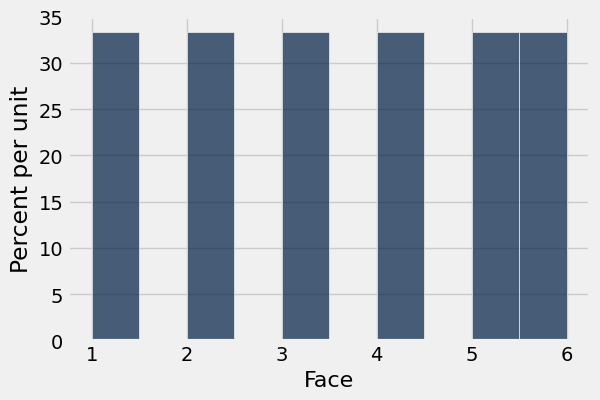

In [4]:
# Draw a histogram
die.hist()

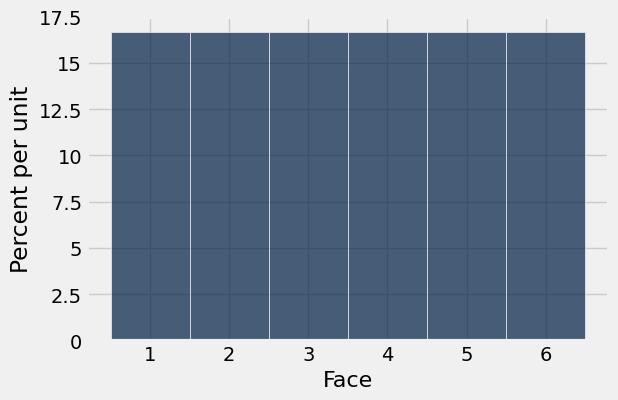

In [5]:
# Ugh that's not very pretty; let's be careful about the bins
roll_bins = np.arange(0.5, 6.6, 1)
die.hist(bins=roll_bins)

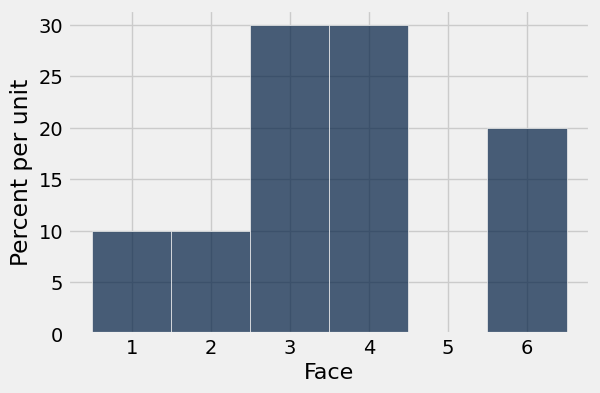

In [6]:
# Now let's see what happens if we introduce randomness into this:

die.sample(10).hist(bins=roll_bins)

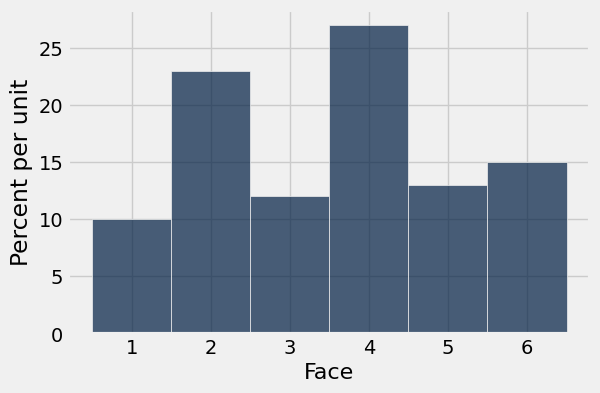

In [7]:
# Let's take a bigger sample:

die.sample(100).hist(bins=roll_bins)

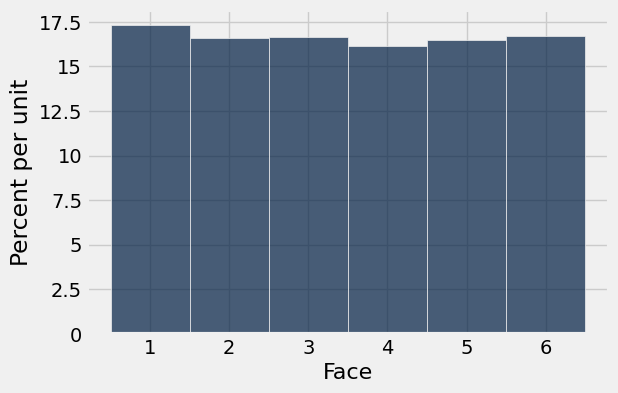

In [8]:
# Let's do an even bigger one:

die.sample(10000).hist(bins=roll_bins)

## Part 2: Distribution of sample averages

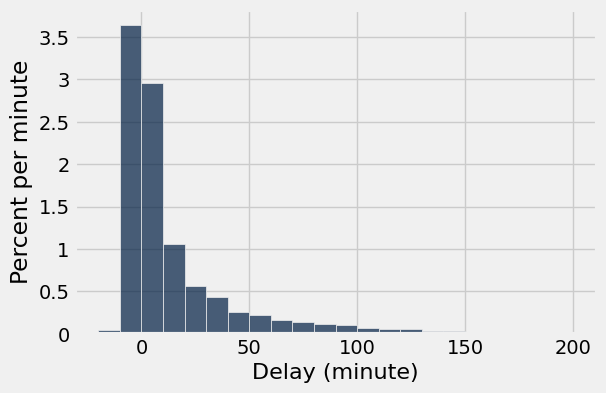

In [9]:
united = Table.read_table('united.csv')
united = united.with_column('Row', np.arange(united.num_rows)).move_to_start('Row')
united
united.hist('Delay', bins = np.arange(-20, 201, 10), unit = 'minute')

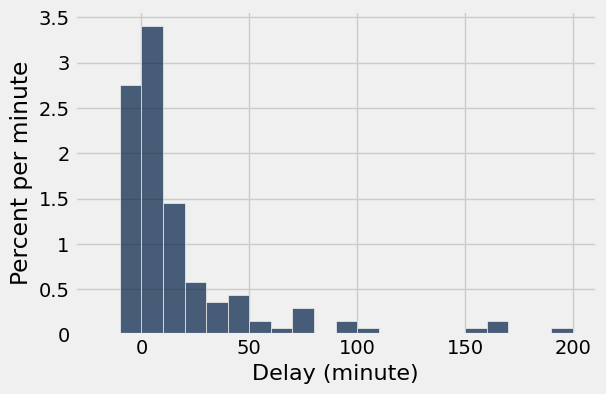

In [10]:
# A random sample: unpack what this code does!
start = np.random.choice(np.arange(100))
systematic_sample = united.take(np.arange(start, united.num_rows, 100))
#systematic_sample
systematic_sample.hist('Delay', bins = np.arange(-20, 201, 10), unit = 'minute')

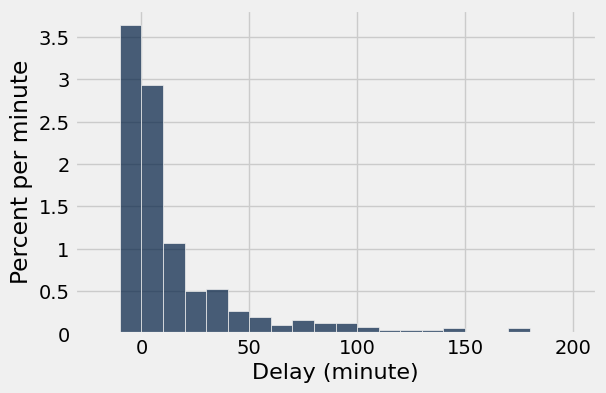

In [11]:
# Now a different random sample: choose 500 flights at random
sample_size = 500
united.sample(sample_size).hist('Delay', bins = np.arange(-20, 201, 10), unit = 'minute')

In [12]:
# Now introduce a STATISTIC
sample_size = 100
delay = np.average(united.column('Delay'))

sample = united.sample(sample_size)
sample_delay = np.average(sample.column('Delay'))

print('Average delay', delay)
print('Sample average', sample_delay)

Average delay 16.6581555154
Sample average 17.53


In [13]:
# Let's generate a bunch of sample averages instead:

def random_sample_average():
    return np.average(united.sample(100).column('Delay'))

sample_averages = make_array()

for _ in np.arange(1000):
    sample_averages = np.append(sample_averages, random_sample_average())

In [14]:
# Now make a table of the data!
sample_average_table = Table().with_columns('Sample average', sample_averages)
sample_average_table

Sample average
16.46
19.31
17.5
11.34
14.27
12.47
18.52
19.22
10.89
13.37


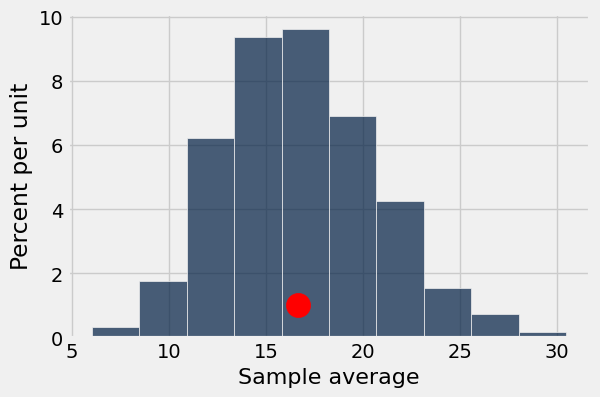

In [46]:
# Now let's look at the distribution of the sample averages

sample_average_table.hist()
plots.scatter(delay, 0.01, color='red', s=300)

## Part 3: Distribution of sample medians

In [16]:
united = Table.read_table('united.csv')
united = united.with_column('Row', np.arange(united.num_rows)).move_to_start('Row')
united

Row,Date,Flight Number,Destination,Delay
0,6/1/15,73,HNL,257
1,6/1/15,217,EWR,28
2,6/1/15,237,STL,-3
3,6/1/15,250,SAN,0
4,6/1/15,267,PHL,64
5,6/1/15,273,SEA,-6
6,6/1/15,278,SEA,-8
7,6/1/15,292,EWR,12
8,6/1/15,300,HNL,20
9,6/1/15,317,IND,-10


In [17]:
# (Population) Parameter
np.median(united.column('Delay'))
#np.average(united.column('Delay'))

2.0

In [18]:
# (Sample) Statistic
np.median(united.sample(10).column('Delay'))

-0.5

In [19]:
# (Sample) Statistic
np.median(united.sample(100).column('Delay'))

0.0

In [20]:
def sample_median(size):
    return np.median(united.sample(size).column('Delay'))

In [21]:
sample_median(10)

1.5

In [22]:
num_simulations = 2000
sample_medians = make_array()

for i in np.arange(num_simulations):
    new_median = sample_median(10)
    sample_medians = np.append(sample_medians, new_median)

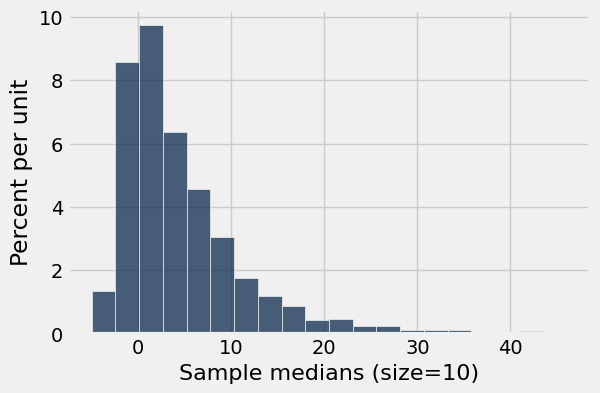

In [23]:
Table().with_column('Sample medians (size=10)', sample_medians).hist(bins=20)

In [24]:
sample_medians = make_array()

for i in np.arange(num_simulations):
    new_median = sample_median(1000)
    sample_medians = np.append(sample_medians, new_median)

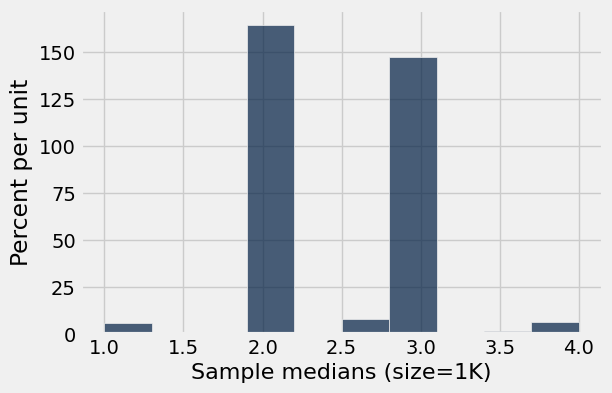

In [25]:
Table().with_column('Sample medians (size=1K)', sample_medians).hist()

#### Empirical Distributions of a Statistic (Overlayed)

In [26]:
sample_medians_10 = make_array()
sample_medians_100 = make_array()
sample_medians_1000 = make_array()

num_simulations = 2000

for i in np.arange(num_simulations):
    new_median_10 = sample_median(10)
    sample_medians_10 = np.append(sample_medians_10, new_median_10)
    new_median_100 = sample_median(100)
    sample_medians_100 = np.append(sample_medians_100, new_median_100)
    new_median_1000 = sample_median(1000)
    sample_medians_1000 = np.append(sample_medians_1000, new_median_1000)

In [27]:
sample_medians = Table().with_columns('Size 10', sample_medians_10, 
                                      'Size 100', sample_medians_100,
                                      'Size 1000', sample_medians_1000)
sample_medians

Size 10,Size 100,Size 1000
0,1,2
-1,5,3
13,4,3
13,3,2
4.5,3,2
0,0.5,2
3,3,2
19,3.5,3
2.5,1,3
0.5,3,1


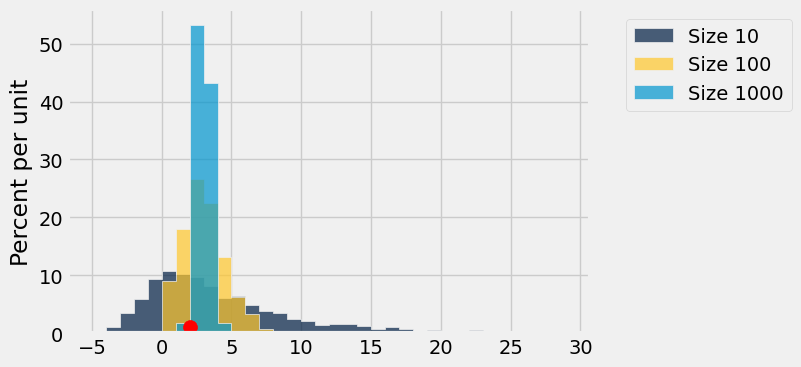

In [47]:
sample_medians.hist(bins = np.arange(-5, 30))

# Put a dot at the true value
true_median = np.median(united.column('Delay'))
plots.scatter(true_median, 0.01, s=100, color='red')

## Part 4: Distribution of sample maximums

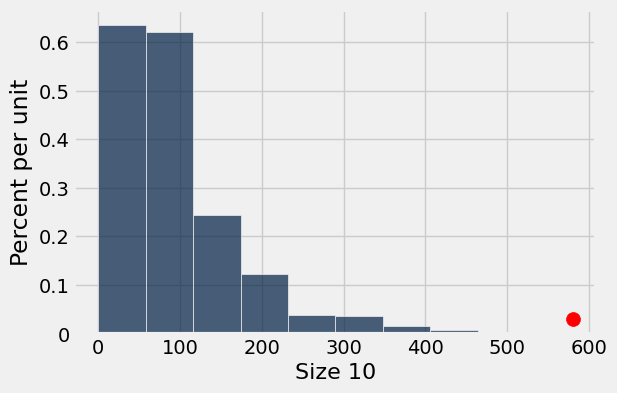

In [49]:
sample_maxes_10 = make_array()
num_simulations = 2000

for i in np.arange(num_simulations):
    sample_maxes_10 = np.append(sample_maxes_10,
                                max(united.sample(10).column('Delay')))

sample_maxes = Table().with_columns('Size 10', sample_maxes_10)
sample_maxes.hist()

# Put a dot at the true max delay
true_max = max(united.column('Delay'))
plots.scatter(true_max, 0.0003, s=100, c='red')

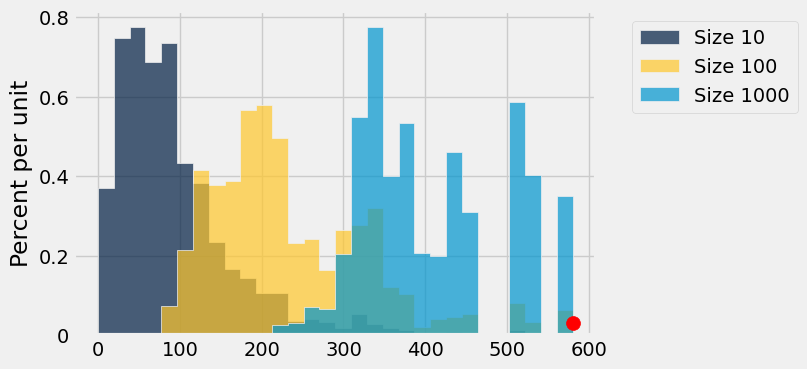

In [48]:
# Let's try again with larger sample sizes:
sample_maxes_10 = make_array()
sample_maxes_100 = make_array()
sample_maxes_1000 = make_array()

num_simulations = 2000

for i in np.arange(num_simulations):
    sample_maxes_10 = np.append(sample_maxes_10,
                                max(united.sample(10).column('Delay')))
    sample_maxes_100 = np.append(sample_maxes_100,
                                max(united.sample(100).column('Delay')))
    sample_maxes_1000 = np.append(sample_maxes_1000,
                                max(united.sample(1000).column('Delay')))

sample_maxes = Table().with_columns(
    'Size 10', sample_maxes_10,
    'Size 100', sample_maxes_100,
    'Size 1000', sample_maxes_1000)

sample_maxes.hist(bins=30)

# Put a dot at the true max delay
true_max = max(united.column('Delay'))
plots.scatter(true_max, 0.0003, s=100, c='red')